In [35]:
import itertools

import numpy as np
import pandas as pd
import yfinance as yf
import random
%matplotlib inline
import matplotlib.pyplot as plt

import torch
from stable_baselines3.common.utils import set_random_seed

from finrl import config_tickers
from finrl.config import INDICATORS, TRAIN_START_DATE, TRAIN_END_DATE, TRADE_START_DATE, TRADE_END_DATE
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from pypfopt.efficient_frontier import EfficientFrontier

In [36]:
tickers = ["AAPL", "MSFT", "JPM", "XOM", "KO"]

train_start = "2018-01-01"
train_end   = "2023-01-01"  
test_start  = "2023-01-01"
test_end    = "2025-01-01"  

In [37]:
train_raw = yf.download(
    tickers=tickers,
    start=train_start,
    end=train_end,
    interval="1d",
    auto_adjust=True,
    group_by="ticker",
    progress=False
)

trade_raw = yf.download(
    tickers=tickers,
    start=test_start,
    end=test_end,
    interval="1d",
    auto_adjust=True,
    group_by="ticker",
    progress=False)

In [38]:
train_raw.head

<bound method NDFrame.head of Ticker            MSFT                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2018-01-02   79.035520   79.200694   78.457415   78.870346  22483800   
2018-01-03   78.971275   79.384213   78.888692   79.237389  26061400   
2018-01-04   79.457658   80.439530   79.439308   79.934830  21912000   
2018-01-05   80.439492   81.127714   80.228434   80.925835  23407100   
2018-01-08   80.935018   81.283722   80.384441   81.008430  22113000   
...                ...         ...         ...         ...       ...   
2022-12-23  230.071553  232.760961  227.957052  232.624542  21207000   
2022-12-27  232.595301  232.819415  229.798706  230.899811  16688600   
2022-12-28  230.831596  233.589221  228.181158  228.531952  17457100   
2022-12-29  229.623287  235.732937  229.623287  234.846207  19770700   
2022-12-30  232.117866  233.823110

In [39]:
trade_raw.head

<bound method NDFrame.head of Ticker            MSFT                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2023-01-03  236.863262  239.464975  231.328520  233.452774  25740000   
2023-01-04  226.339464  226.914371  220.181105  223.240799  50623400   
2023-01-05  221.389420  221.730475  216.088544  216.624481  39585600   
2023-01-06  217.296811  219.986219  213.740165  219.177444  43613600   
2023-01-09  220.658599  225.326105  220.619629  221.311462  27369800   
...                ...         ...         ...         ...       ...   
2024-12-24  430.484578  435.387152  430.028995  435.119720   7164500   
2024-12-26  434.872113  436.714303  432.445610  433.911407   8194200   
2024-12-27  430.435056  431.049109  422.264119  426.404053  18117700   
2024-12-30  421.976951  423.452663  417.856814  420.758728  13158700   
2024-12-31  422.016524  422.640492

In [40]:
def process_yf_to_finrl(df, tickers):
    temp_df = df.stack(level=0).reset_index()
    temp_df.columns = ['date', 'tic', 'open', 'high', 'low', 'close', 'volume']

    temp_df['date'] = temp_df['date'].dt.strftime('%Y-%m-%d')
    return temp_df


train_processed_raw = process_yf_to_finrl(train_raw, tickers)
trade_processed_raw = process_yf_to_finrl(trade_raw, tickers)

/var/folders/f1/bl9pdng10rb80hc7kt_4h8s00000gn/T/ipykernel_69864/2626236642.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  temp_df = df.stack(level=0).reset_index()
/var/folders/f1/bl9pdng10rb80hc7kt_4h8s00000gn/T/ipykernel_69864/2626236642.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  temp_df = df.stack(level=0).reset_index()


In [ ]:
fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS,  
    use_vix=False,                  
    use_turbulence=False,            
    user_defined_feature=False,
)


train_fe = fe.preprocess_data(train_processed_raw)
trade_fe = fe.preprocess_data(trade_processed_raw)

Successfully added technical indicators
Successfully added technical indicators


In [ ]:


def clean_data(df):
    list_ticker = df["tic"].unique().tolist()
    list_date = list(pd.date_range(df["date"].min(), df["date"].max()).astype(str))
    
    combination = list(itertools.product(list_date, list_ticker))
    processed_full = pd.DataFrame(combination, columns=["date", "tic"])
    

    processed_full = processed_full.merge(df, on=["date", "tic"], how="left")
    processed_full = processed_full[processed_full["date"].isin(df["date"])]
    processed_full = processed_full.sort_values(["date", "tic"])
    processed_full = processed_full.fillna(0)  #
    return processed_full

train_final = clean_data(train_fe)
trade_final = clean_data(trade_fe)

In [43]:

train_final.index = train_final["date"].factorize()[0]
trade_final.index = trade_final["date"].factorize()[0]

In [44]:


def set_global_seed(seed=123):

    random.seed(seed)
    

    np.random.seed(seed)
    
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    set_random_seed(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_global_seed(123)

In [ ]:
stock_dimension = len(train_final["tic"].unique())
state_space = 1 + 2 * stock_dimension + len(INDICATORS) * stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "num_stock_shares": [0] * stock_dimension,
    "buy_cost_pct": [0.001] * stock_dimension,
    "sell_cost_pct": [0.001] * stock_dimension,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4
}

e_train_gym = StockTradingEnv(df=train_final, **env_kwargs)
env_train, _ = e_train_gym.get_sb_env()


Stock Dimension: 5, State Space: 51


In [ ]:
agent = DRLAgent(env=env_train)

model_a2c = agent.get_model("a2c")
trained_a2c = agent.train_model(model=model_a2c, tb_log_name="a2c", total_timesteps=10000)


{'n_steps': 5, 'ent_coef': 0.01, 'learning_rate': 0.0007}
Using cpu device
---------------------------------------
| time/                 |             |
|    fps                | 1026        |
|    iterations         | 100         |
|    time_elapsed       | 0           |
|    total_timesteps    | 500         |
| train/                |             |
|    entropy_loss       | -7.34       |
|    explained_variance | 0           |
|    learning_rate      | 0.0007      |
|    n_updates          | 99          |
|    policy_loss        | 0.0948      |
|    reward             | 0.011596829 |
|    std                | 1.05        |
|    value_loss         | 0.00063     |
---------------------------------------
-------------------------------------
| time/                 |           |
|    fps                | 1086      |
|    iterations         | 200       |
|    time_elapsed       | 0         |
|    total_timesteps    | 1000      |
| train/                |           |
|    entropy_loss  

In [47]:

PPO_PARAMS = {
    "n_steps": 2048,
    "ent_coef": 0.01,
    "learning_rate": 0.00025,
    "batch_size": 128,
}
model_ppo = agent.get_model("ppo", model_kwargs=PPO_PARAMS)
trained_ppo = agent.train_model(model=model_ppo, tb_log_name="ppo", total_timesteps=10000)

{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 128}
Using cpu device
day: 1258, episode: 10
begin_total_asset: 1000000.00
end_total_asset: 1167109.52
total_reward: 167109.52
total_cost: 36697.56
total_trades: 6086
Sharpe: 0.318
----------------------------------
| time/              |           |
|    fps             | 1622      |
|    iterations      | 1         |
|    time_elapsed    | 1         |
|    total_timesteps | 2048      |
| train/             |           |
|    reward          | -1.116876 |
----------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1497         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.004444626  |
|    clip_fraction        | 0.0468       |
|    clip_range           | 0.2          

In [ ]:
e_trade_gym_a2c = StockTradingEnv(df=trade_final, **env_kwargs)
e_trade_gym_ppo = StockTradingEnv(df=trade_final, **env_kwargs)

df_account_value_a2c, df_actions_a2c = DRLAgent.DRL_prediction(
    model=trained_a2c, 
    environment=e_trade_gym_a2c
)

df_account_value_ppo, df_actions_ppo = DRLAgent.DRL_prediction(
    model=trained_ppo, 
    environment=e_trade_gym_ppo
)

hit end!
hit end!


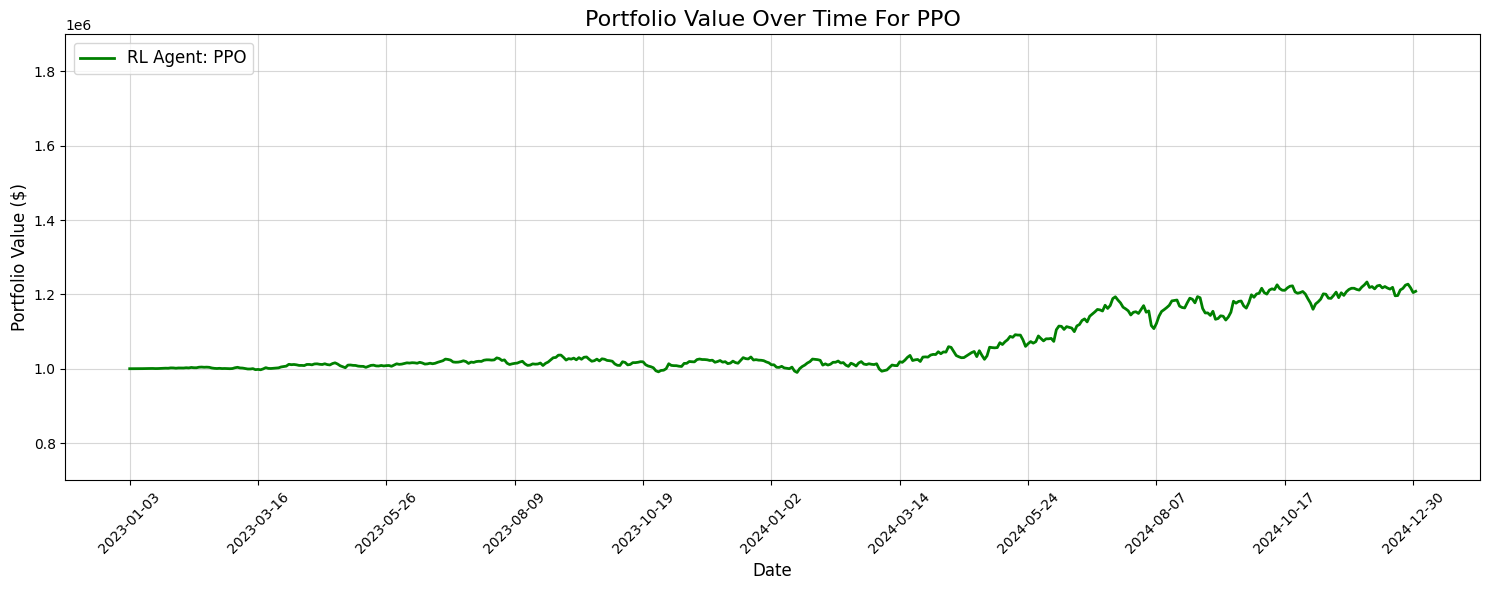

In [ ]:
result_df = df_account_value_ppo[["date", "account_value"]].rename(columns={"account_value": "PPO"})
plt.figure(figsize=(15, 6))
plt.plot(result_df["date"], result_df["PPO"], label="RL Agent: PPO", linewidth=2, color="green")
plt.title("Portfolio Value Over Time For PPO", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.ylim(0.7e6, 1.9e6)
plt.legend(fontsize=12, loc="upper left")
plt.grid(True, alpha=0.5)

xticks_interval = max(1, len(result_df) // 10)
plt.xticks(result_df["date"][::xticks_interval], rotation=45)

plt.tight_layout()
plt.show()

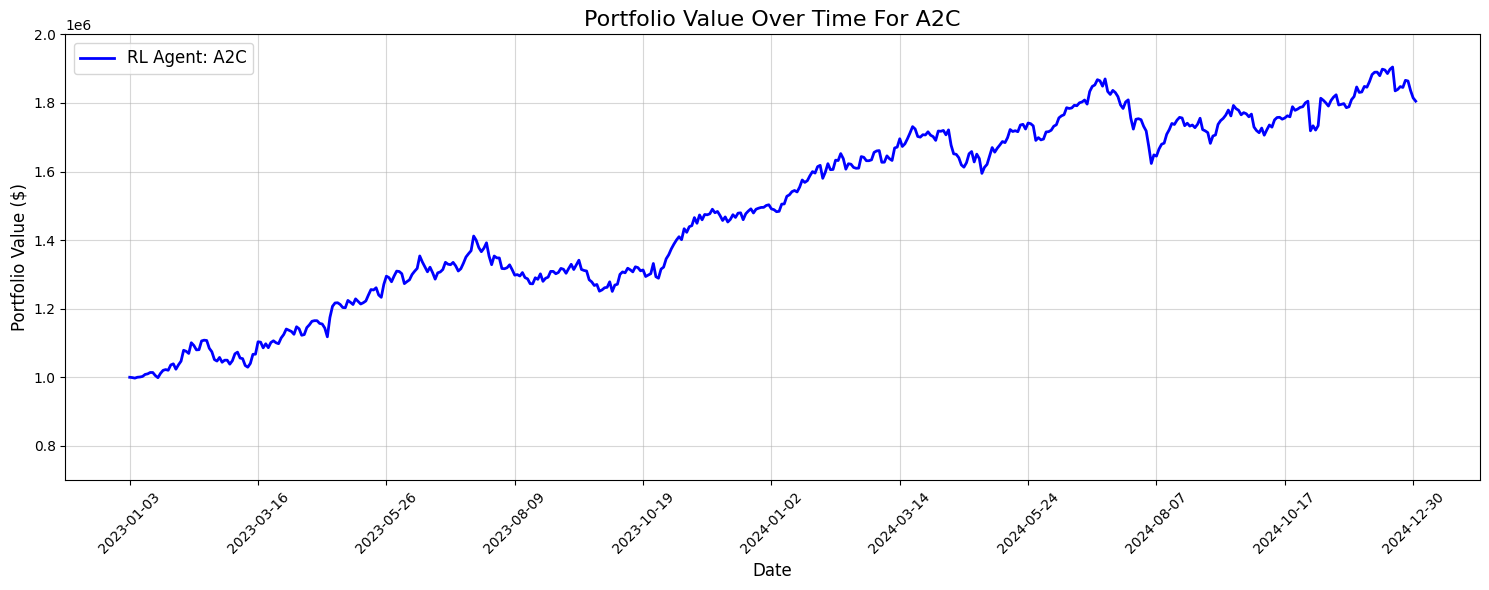

In [ ]:
result_df = df_account_value_a2c[["date", "account_value"]].rename(columns={"account_value": "A2C"})
plt.figure(figsize=(15, 6))
plt.plot(result_df["date"], result_df["A2C"], label="RL Agent: A2C", linewidth=2, color="blue")
plt.title("Portfolio Value Over Time For A2C", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.ylim(0.7e6, 2e6)
plt.legend(fontsize=12, loc="upper left")
plt.grid(True, alpha=0.5)

xticks_interval = max(1, len(result_df) // 10)
plt.xticks(result_df["date"][::xticks_interval], rotation=45)

plt.tight_layout()
plt.show()